<a href="https://colab.research.google.com/github/NietoEmmanuel/SIMULACION-II/blob/main/Caminata_aleatoria_sobre_un_grafo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAMINATA ALEATORIA SOBRE UN GRAFO

La cadena de Markov se construye mediante una caminata aleatoria sobre un grafo cuyos vértices representan secuencias buenas. Una secuencia buena es aquella formada por ceros y unos que no contiene dos unos consecutivos.

El procedimiento de la caminata aleatoria es el siguiente:

1. Dada una secuencia buena de longitud $m$, se selecciona uniformemente al azar una de sus $m$ componentes.

2. Si la componente seleccionada es $1$, se cambia por $0$. Como el número de unos disminuye, la secuencia resultante sigue siendo buena y la caminata se mueve a la nueva secuencia.

3. Si la componente seleccionada es $0$, se propone cambiarla por $1$. Si la secuencia resultante sigue siendo buena, se acepta el cambio y la caminata se mueve a la nueva secuencia. En caso contrario, se rechaza el cambio y la caminata permanece en el estado actual.

Esta caminata puede representarse mediante un grafo ponderado, donde dos secuencias buenas que difieren en una sola componente están conectadas por una arista de peso $1$. Además, cada vértice puede tener un lazo cuyo peso permite que la suma de los pesos de las aristas incidentes sea igual a $m$.

Como todos los vértices tienen el mismo peso total, la distribución estacionaria de la cadena de Markov es uniforme sobre todas las secuencias buenas.

El objetivo es estimar el número esperado de unos en una secuencia buena de longitud $m$. Para ello, se realiza una simulación mediante una caminata aleatoria y se calcula el promedio del número de unos observados durante los pasos de la simulación.

Ver Figura para la construcción del gráfico ponderado para m = 4:

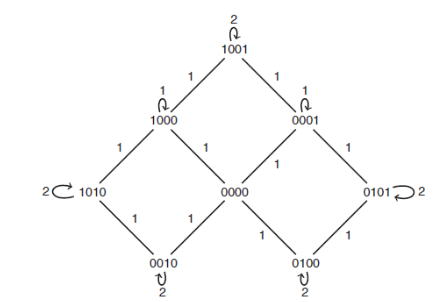

In [1]:
import random as r
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Definir el tamaño de la cadena y el numero de pasos
m = 1000
n = 50000

# Empezar con una cadena buena
cadena = [0] * m

# Guardar el numero de unos en cada paso
unos = np.zeros(n)

In [3]:
# Caminata aleatoria
for i in range(1, n):

    # Elegir una posicion al azar
    pos = r.randint(0, m - 1)

    # Proponer un cambio
    nueva = cadena.copy()

    if nueva[pos] == 1:
        nueva[pos] = 0
        cadena = nueva

    else:
        nueva[pos] = 1

        # Revisar si la cadena es buena
        buena = True

        for j in range(m - 1):
            if nueva[j] == 1 and nueva[j + 1] == 1:
                buena = False

        # Aceptar el cambio si es buena
        if buena:
            cadena = nueva

    # Guardar el numero de unos
    unos[i] = sum(cadena)

In [6]:
# Calcular el valor esperado
esperanza = np.mean(unos[1000:])

print("Tamaño de la cadena =", m)
print("Numero de pasos =", n)
print("Numero esperado de unos en una buena cadena =", esperanza)

Tamaño de la cadena = 1000
Numero de pasos = 50000
Numero esperado de unos en una buena cadena = 274.1910612244898


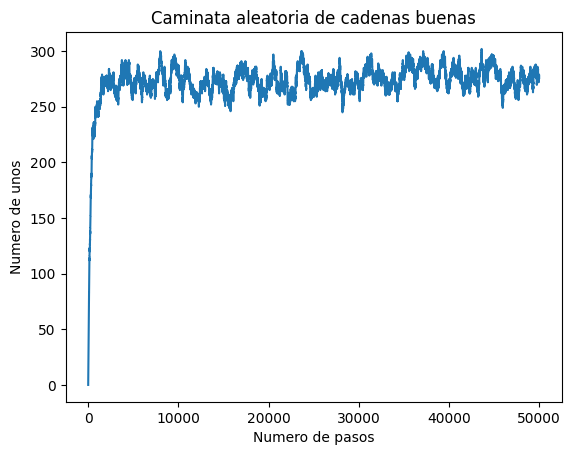

In [5]:
# Graficar la caminata
plt.title("Caminata aleatoria de cadenas buenas")
plt.plot(unos)
plt.xlabel("Numero de pasos")
plt.ylabel("Numero de unos")
plt.show()